In [13]:
from typing import TypedDict, Literal

class AmountState(TypedDict):
    amount_usd: float
    total_usd:float
    target_currency: Literal["eur", "inr"]
    total: float
    

In [20]:
import requests

def cal_total(state:AmountState) -> AmountState:
    state['total_usd'] = state['amount_usd'] * 1.08
    return state

def convert_to_inr(state:AmountState) -> AmountState:
    url = "https://api.freecurrencyapi.com/v1/latest?apikey=fca_live_515woyclxesue2LdNSmoH3Vr3QwBj5BfPkEq0hr3&currencies=INR&base_currency=USD"
    
    resp = requests.get(url)

    con_rate = float(resp.json().get("data").get("INR"))
    state['total'] = state['total_usd'] * con_rate
    return state

def convert_to_eur(state:AmountState) -> AmountState:
    url = "https://api.freecurrencyapi.com/v1/latest?apikey=fca_live_515woyclxesue2LdNSmoH3Vr3QwBj5BfPkEq0hr3&currencies=EUR&base_currency=USD"
    
    resp = requests.get(url)

    con_rate = float(resp.json().get("data").get("EUR"))
    state['total'] = state['total_usd'] * con_rate
    return state

def choose_conversion(state:AmountState) -> str:
    return state['target_currency']

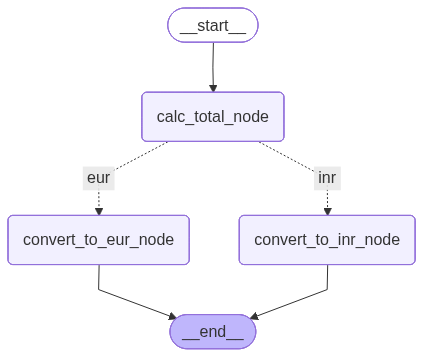

In [21]:
from langgraph.graph  import StateGraph,END,START

builder = StateGraph(AmountState)

builder.add_node("calc_total_node",cal_total)
builder.add_node("convert_to_inr_node",convert_to_inr)
builder.add_node("convert_to_eur_node",convert_to_eur)

builder.add_edge(START, "calc_total_node")

builder.add_conditional_edges(
    "calc_total_node",
    choose_conversion,
    {
        "inr": "convert_to_inr_node",
        "eur": "convert_to_eur_node"
    }
)

builder.add_edge(["convert_to_inr_node","convert_to_eur_node"],END)

graph = builder.compile()
graph


In [22]:
graph.invoke({"amount_usd": 100, "target_currency": "eur"})

{'amount_usd': 100,
 'total_usd': 108.0,
 'target_currency': 'eur',
 'total': 91.5067955736}